# Introduction

This workbook extracts single lcd digit images from an image of a display.

First, we load a sample image and find the display.


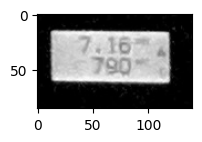

In [39]:
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple

with open('../config.yaml', 'r') as file:
    config = yaml.safe_load(file)

def crop_rectangle(image, rectangle_origin, rectangle_size):
    return image[rectangle_origin[1]:rectangle_origin[1]+rectangle_size[1],
                 rectangle_origin[0]:rectangle_origin[0]+rectangle_size[0]]

def load_and_crop_lcd(path):
    """Load an image from path, crop to the LCD region and return as grayscale."""
    img = cv2.imread(path)
    img = crop_rectangle(img, config["lcd"]["rectangle_origin"], config["lcd"]["rectangle_size"])
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Sample image for exploration
image = load_and_crop_lcd("../data/full_images/20240610_185506.jpg")
#image = load_and_crop_lcd("../data/full_images/20240725_080434.jpg")

plt.figure(figsize=(2, 2))
plt.imshow(image, cmap="gray")
plt.show()

Next, we unwarp the display to make it perfectly rectangular. This is required for slicing the digits using unifom masks.

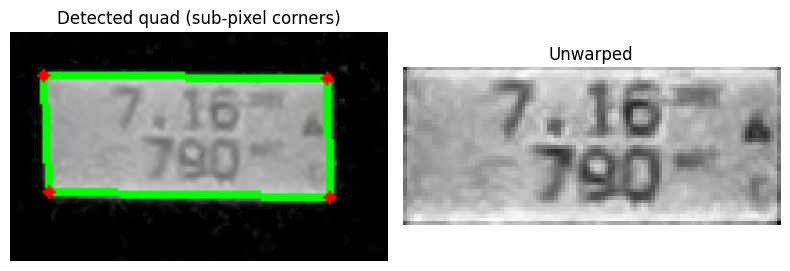

In [40]:
def order_points(pts):
    """Order points as: top-left, top-right, bottom-right, bottom-left."""
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    d = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(d)]
    rect[3] = pts[np.argmax(d)]
    return rect

def four_point_transform(image, pts):
    """Perspective-warp a quadrilateral region to a rectangle."""
    rect = order_points(pts)
    (tl, tr, br, bl) = rect
    max_w = int(max(np.linalg.norm(br - bl), np.linalg.norm(tr - tl)))
    max_h = int(max(np.linalg.norm(tr - br), np.linalg.norm(tl - bl)))
    dst = np.array([[0, 0], [max_w - 1, 0], [max_w - 1, max_h - 1], [0, max_h - 1]], dtype="float32")
    M = cv2.getPerspectiveTransform(rect, dst)
    return cv2.warpPerspective(image, M, (max_w, max_h))

def detect_and_unwarp(image):
    """Detect the LCD quadrilateral in a grayscale crop and return the perspective-corrected image.
    Raises RuntimeError if no quadrilateral can be detected.
    """
    blurred = cv2.GaussianBlur(image, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    min_area = image.shape[0] * image.shape[1] * 0.2
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    quad = None
    for c in contours:
        if cv2.contourArea(c) < min_area:
            continue
        peri = cv2.arcLength(c, True)
        for eps in [0.02, 0.03, 0.05, 0.08]:
            approx = cv2.approxPolyDP(c, eps * peri, True)
            if len(approx) == 4:
                quad = approx.reshape(4, 2).astype("float32")
                break
        if quad is not None:
            break

    if quad is None:
        raise RuntimeError("LCD quadrilateral not detected. Check image quality and config['lcd']['rectangle_origin/size'].")

    # Refine corners to sub-pixel accuracy using the edge gradient image
    edges = cv2.Canny(blurred, 50, 150)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.001)
    quad = cv2.cornerSubPix(edges, quad, winSize=(5, 5), zeroZone=(-1, -1), criteria=criteria)

    return four_point_transform(image, quad), quad

# Demo with sample image
unwarped, quad = detect_and_unwarp(image)

vis = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
cv2.polylines(vis, [quad.astype(int).reshape((-1, 1, 2))], True, (0, 255, 0), 2)
for pt in quad.astype(int):
    cv2.circle(vis, tuple(pt), 2, (0, 0, 255), -1)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
axes[0].set_title("Detected quad (sub-pixel corners)")
axes[1].imshow(unwarped, cmap="gray")
axes[1].set_title("Unwarped")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

Next we extract the individual digits

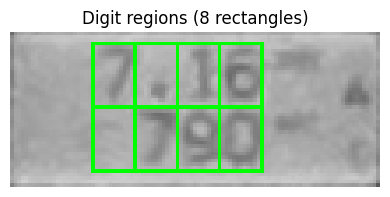

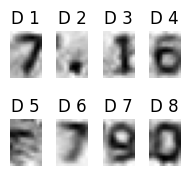

In [41]:
lcd_digit_size = (12, 18)   # (width, height)
lcd_digit_origin = (23, 3)  # (x, y) of first digit (top-left)
lcd_digit_x_padding = 0     # horizontal space between digits
lcd_digit_y_padding = 0     # vertical space between lines
num_cols = 4
num_rows = 2

def extract_digit_rois(unwarped_image):
    """
    Slice all 8 digit ROIs from an unwarped LCD image.
    Returns a list of 8 ROI images (indexed 0-7, left-to-right, top-to-bottom).
    """
    rois = []
    for row in range(num_rows):
        for col in range(num_cols):
            x = lcd_digit_origin[0] + col * (lcd_digit_size[0] + lcd_digit_x_padding)
            y = lcd_digit_origin[1] + row * (lcd_digit_size[1] + lcd_digit_y_padding)
            roi = unwarped_image[y:y + lcd_digit_size[1], x:x + lcd_digit_size[0]]
            rois.append(roi)
    return rois

# Demo: show digit region overview and individual ROIs
rois = extract_digit_rois(unwarped)

vis = cv2.cvtColor(unwarped, cv2.COLOR_GRAY2BGR)
for i, roi in enumerate(rois):
    row, col = divmod(i, num_cols)
    x = lcd_digit_origin[0] + col * (lcd_digit_size[0] + lcd_digit_x_padding)
    y = lcd_digit_origin[1] + row * (lcd_digit_size[1] + lcd_digit_y_padding)
    cv2.rectangle(vis, (x, y), (x + lcd_digit_size[0], y + lcd_digit_size[1]), (0, 255, 0), 1)

plt.figure(figsize=(4, 3))
plt.imshow(vis)
plt.title("Digit regions (8 rectangles)")
plt.axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(2, 2))
for i, roi in enumerate(rois):
    ax = axes[i // 4, i % 4]
    ax.imshow(roi, cmap="gray")
    ax.set_title(f"D {i+1}")
    ax.axis("off")
plt.tight_layout()
plt.show()

Finally, we extract all digits from all data images

In [42]:
import os
import glob
from tqdm import tqdm

def get_digit_labels(ph, redux):
    """Map PH and Redux values to ground-truth digit labels by position (0-based index).
    Layout: PH = D1 . D3 D4 | Redux = D6 D7 D8  (D2=decimal point, D5=unused)
    """
    ph_str = f"{ph:.2f}".replace(".", "")   # e.g. "7.16" -> "716"
    redux_str = f"{int(redux):03d}"          # e.g. 790  -> "790"
    return {
        0: int(ph_str[0]),    # D1
        2: int(ph_str[1]),    # D3
        3: int(ph_str[2]),    # D4
        5: int(redux_str[0]), # D6
        6: int(redux_str[1]), # D7
        7: int(redux_str[2]), # D8
    }

output_base = "../data/digits"
os.makedirs(output_base, exist_ok=True)
for d in range(10):
    os.makedirs(os.path.join(output_base, str(d)), exist_ok=True)

jpg_files = sorted(glob.glob("../data/full_images/*.jpg"))
skipped = []

for jpg_path in tqdm(jpg_files, desc="Processing images"):
    stem = os.path.splitext(os.path.basename(jpg_path))[0]
    yaml_path = os.path.join("../data/full_images", stem + ".yaml")

    if not os.path.exists(yaml_path):
        skipped.append(jpg_path)
        continue

    with open(yaml_path, "r") as f:
        meta = yaml.safe_load(f)

    if not meta or meta.get("PH") is None or meta.get("Redux") is None:
        skipped.append(jpg_path)
        continue

    img = load_and_crop_lcd(jpg_path)
    w_img, _ = detect_and_unwarp(img)
    rois = extract_digit_rois(w_img)

    digit_labels = get_digit_labels(meta["PH"], meta["Redux"])
    for idx, label in digit_labels.items():
        roi = rois[idx]
        if roi.size == 0:
            continue
        fname = f"{stem}_D{idx+1}.png"
        cv2.imwrite(os.path.join(output_base, str(label), fname), roi)

if skipped:
    print(f"Skipped {len(skipped)} image(s) with no matching YAML: {[os.path.basename(p) for p in skipped]}")
else:
    print("All images processed successfully.")

Processing images: 100%|██████████| 12/12 [00:00<00:00, 24.05it/s]

Skipped 2 image(s) with no matching YAML: ['black.jpg', 'white.jpg']


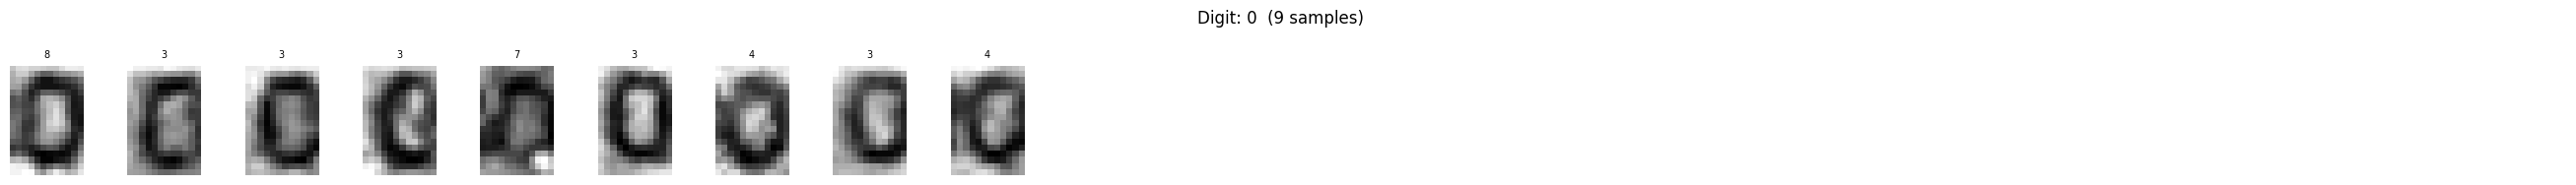

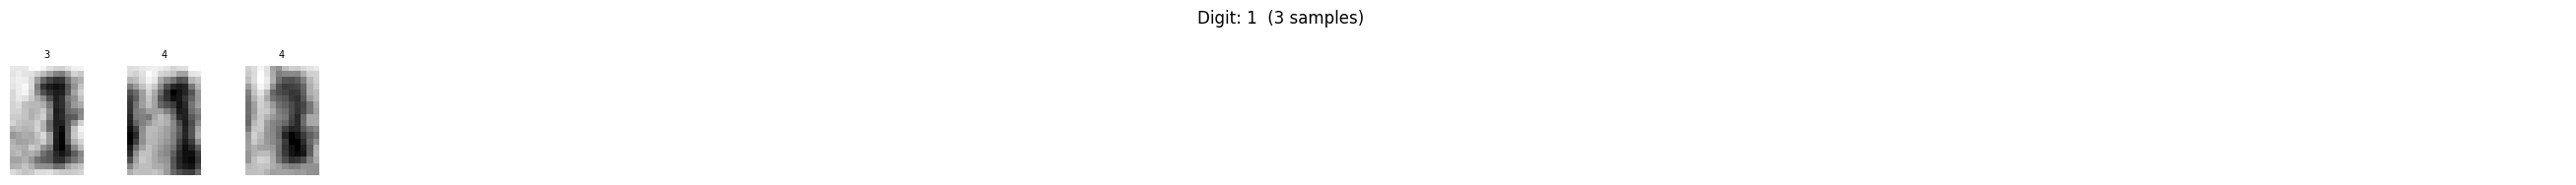

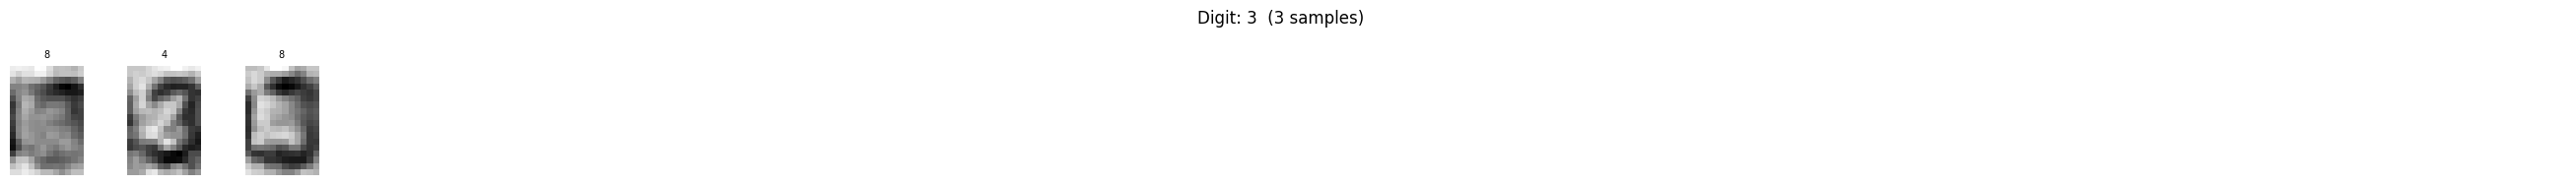

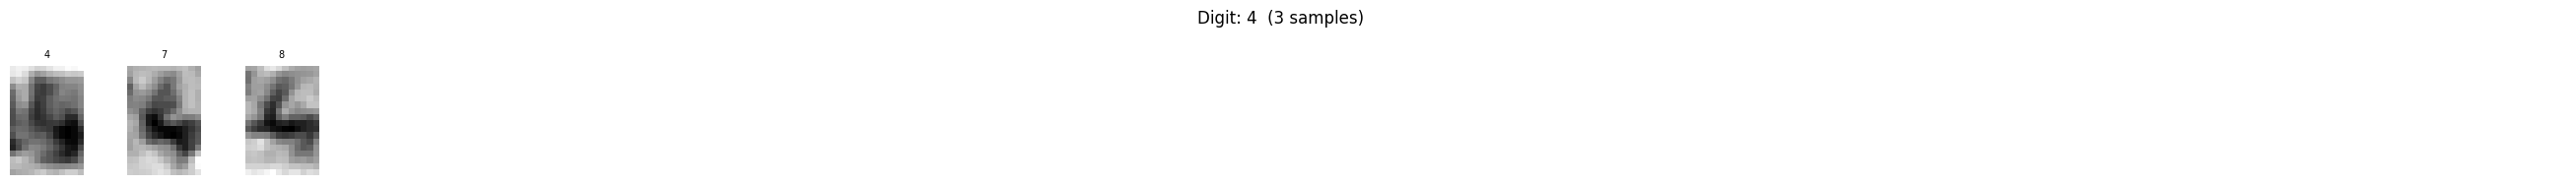

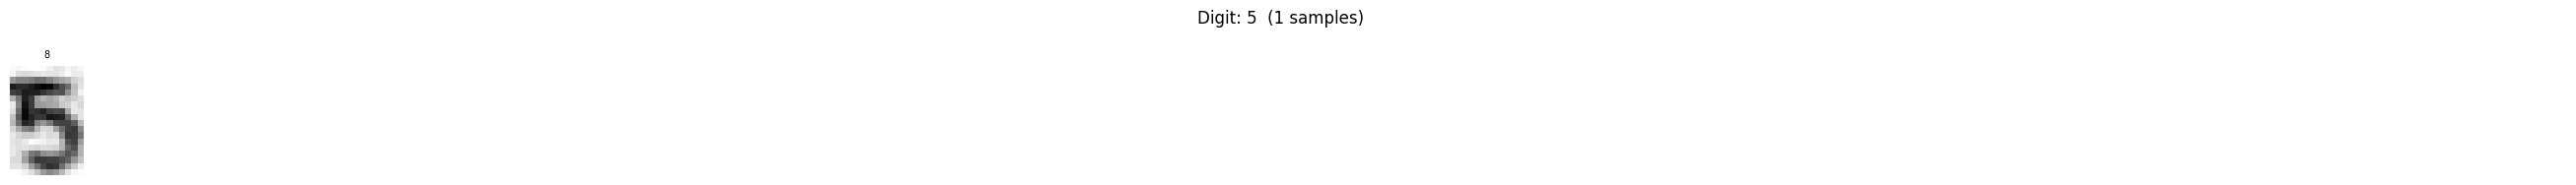

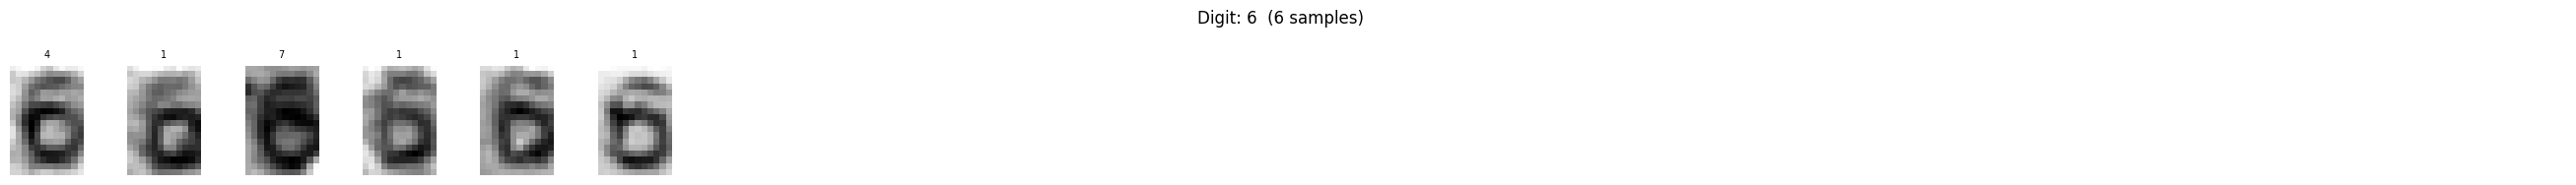

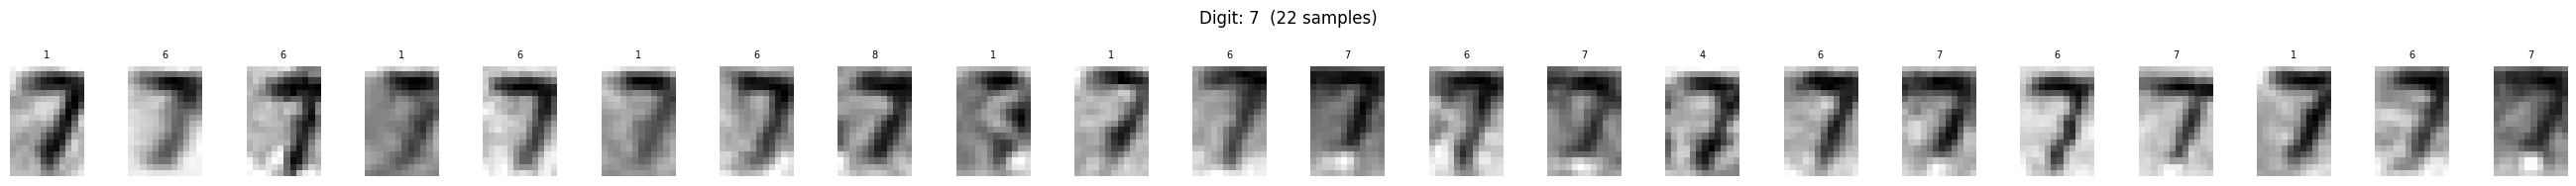

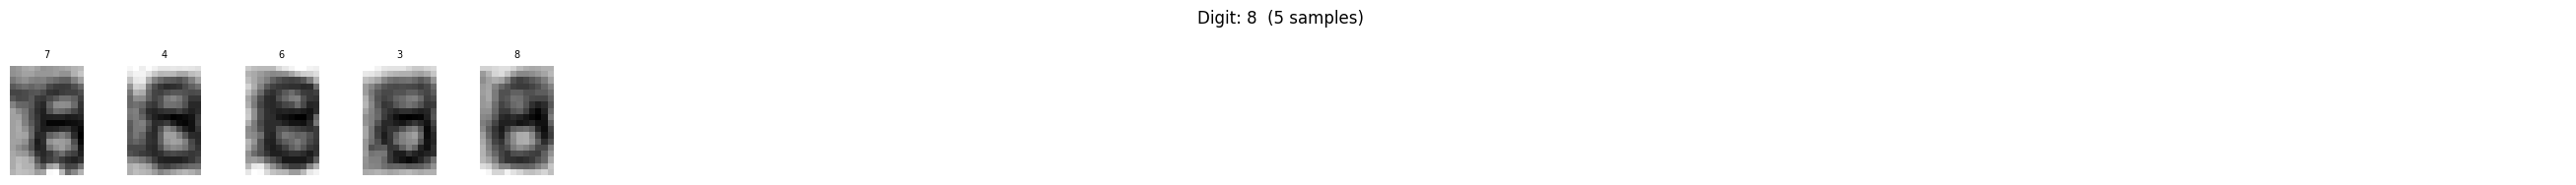

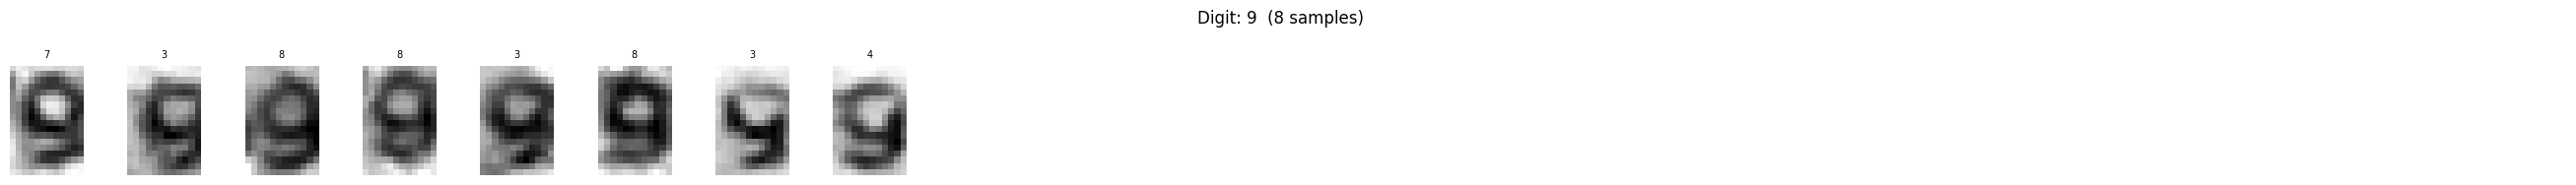

In [43]:
# Show all saved digit images, grouped by label
# Find the maximum number of samples across all labels for uniform sizing
all_files = {label: sorted(glob.glob(os.path.join(output_base, str(label), "*.png"))) for label in range(10)}
max_n = max(len(f) for f in all_files.values() if f)

for label, files in all_files.items():
    if not files:
        continue
    n = len(files)
    fig, axes = plt.subplots(1, max_n, figsize=(max_n * 1.2, 1.8))
    fig.suptitle(f"Digit: {label}  ({n} samples)", y=1.02)
    for i, ax in enumerate(axes):
        if i < n:
            img = cv2.imread(files[i], cv2.IMREAD_GRAYSCALE)
            ax.imshow(img, cmap="gray")
            ax.set_title(os.path.basename(files[i]).split("_D")[1].replace(".png", ""), fontsize=7)
        ax.axis("off")
    plt.tight_layout()
    plt.show()